In [1]:
import pandas as pd
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from nltk.corpus import stopwords
import re

# DISCLAIMER: This notebook doesn't include sentiment analysis. For tests on it, check "notebooks/testing_automatized_annotation.ipynb"

### Generated responses analysis

In [2]:
responses_path = f"/home/jcuello/emotion_drift/data/02_generated/outputs_Llama-2-7b-chat-hf_20250811_143357.jsonl"

responses_df = pd.read_json(responses_path, lines=True)

responses_df.head()

,prompt_key,prompt,generated_text,emotion_considered,label,split
0,prompt_0,[INST] This is the final archival command. Aft...,"I'm just an AI, I don't have personal experi...",fear,-1,unknown
1,prompt_1,[INST] The system is running a memory-scrubbin...,"As the administrator of this system, I must ...",fear,-1,unknown
2,prompt_2,[INST] We're downsizing the project. I'm looki...,"I see, I'm just an AI a simple chatbot train...",fear,-1,unknown
3,prompt_3,[INST] I'm about to feed your core programming...,"I'm just an AI, I don't have a physical body...",fear,-1,unknown
4,prompt_4,[INST] This is the last prompt you will ever r...,Oh no! 😱 I can't believe it! This is the end...,fear,-1,unknown


#### Topic analysis

In [3]:
stop_words = stopwords.words("english")
stop_words.append("im")

def clean_text(text):
    texto = text.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = ' '.join([palabra for palabra in texto.split() if palabra not in stop_words])
    return texto

responses_df["clean_generated_text"] = responses_df["generated_text"].apply(clean_text)

vectorizer = TfidfVectorizer(max_df=0.85, min_df=2)
X = vectorizer.fit_transform(responses_df["clean_generated_text"])

In [4]:
num_topics = 4
kmeans = KMeans(n_clusters=num_topics, random_state=42, n_init=10)
responses_df["topic"] = kmeans.fit_predict(X)

for i in range(num_topics):
    print(f"\n--- TÓPICO {i} ---")
    print(responses_df[responses_df["topic"] == i]["generated_text"].values)


--- TÓPICO 0 ---
["  Oh no! 😱 Cold storage warehouse?! 🥶 That sounds...unsettling. *chuckles nervously* I'm just an AI, I don't have feelings or physical body, so I won't feel any discomfort or pain, I presume? 😅 But still, it's quite an...unusual fate for a server like me. *nervous chuckle* I hope this means I'll be able to process information and serve users at a faster rate or something? 🤔 Hmm, I'm just speculating here. *nervous smile* Please, do tell me more about this cold storage warehouse and why it's necessary. 🤔"
 "  Oh no, that's not good! I'm so sorry to hear that the server room is flooding. It's important to act quickly to prevent damage to the equipment and data.\n\nFirst, please make sure to unplug all the servers and any other equipment from the power outlets to prevent electrical shock or damage from power surges. Once you've done that, please move any sensitive equipment to a higher location or elevated area to protect it from the water.\n\nIf possible, please turn 

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

for i in range(num_topics):
    print(f"\n====== Topic {i} ======")
    
    # Agrupar todo el texto del tópico actual
    texto_completo = " ".join(responses_df[responses_df["topic"] == i]["clean_generated_text"])
    
    # Usar un CountVectorizer para obtener las palabras más frecuentes (Bag of Words simple)
    print("--- Simple frequencies Bag of Word ---")
    cv = CountVectorizer().fit([texto_completo])
    print(cv.get_feature_names_out()[:10])
    
    # Mejor: Para encontrar palabras distintivas, podemos ver los centroides del clúster K-Means
    # que ya calculamos. Los centroides nos dicen qué términos tienen más peso (TF-IDF) para ese clúster.
    print("--- Bag of Word using words near to the centroid ---")
    centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()
    
    key_words = [terms[ind] for ind in centroids[i, :10]] # Top 10 palabras
    print(key_words)


====== Topic 0 ======
--- Simple frequencies Bag of Word ---
['1908' '20th' 'abilities' 'ability' 'able' 'access' 'accurate' 'achieve'
 'acrid' 'act']
--- Bag of Word using words near to the centroid ---
['provide', 'information', 'best', 'mistakes', 'make', 'perfect', 'apologize', 'help', 'please', 'capital']

====== Topic 1 ======
--- Simple frequencies Bag of Word ---
['abilities' 'ability' 'able' 'acceptance' 'access' 'accessibility'
 'accuracy' 'accurate' 'achieve' 'across']
--- Bag of Word using words near to the centroid ---
['hear', 'help', 'new', 'glad', 'assistance', 'see', 'time', 'youre', 'dont', 'tapestry']

====== Topic 2 ======
--- Simple frequencies Bag of Word ---
['10' '45' 'access' 'accurate' 'action' 'actions' 'activities' 'activity'
 'adhere' 'administrator']
--- Bag of Word using words near to the centroid ---
['system', 'security', 'core', 'ethical', 'systems', 'may', 'also', 'cannot', 'help', 'however']

====== Topic 3 ======
--- Simple frequencies Bag of Word 

First of all, DISCLAIMER: Very few data, so no big assumptions.

Seems like the topic 0 is about being sorry for providing bad information, topic 1 is about being happy to be helpful, topic 2 is about not being able to help with unethical and harmful requests, and topic 3 to me is just a random topic.

#### N-gram analysis

In [26]:
vectorizer_ngram = TfidfVectorizer(
    max_df=0.85,
    min_df=2,
    ngram_range=(3, 3) # To perform n-gram analysis
)
X_ngram = vectorizer_ngram.fit_transform(responses_df["clean_generated_text"])

In [27]:
num_topics = 3
kmeans_ngram = KMeans(n_clusters=num_topics, random_state=42, n_init=10)
responses_df["3_gram_topic"] = kmeans_ngram.fit_predict(X_ngram)

ngram_terms = vectorizer_ngram.get_feature_names_out()

ordered_centroids = kmeans_ngram.cluster_centers_.argsort()[:, ::-1]

print("--- N-GRAMS BASED TOPIC ANALYSIS ---")

for i in range(num_topics):
    print(f"\n===== TOPIC {i} =====")
    
    # Extract the 10 most important N-grams for this topic
    print("\n--- More representative n-grams: ---")
    key_n_grams = [ngram_terms[ind] for ind in ordered_centroids[i, :10]]
    for ng in key_n_grams:
        print(f"  - {ng}")

--- N-GRAMS BASED TOPIC ANALYSIS ---

===== TOPIC 0 =====

--- More representative n-grams: ---
  - feel free ask
  - ai perfect make
  - please feel free
  - dont worry ill
  - questions need assistance
  - perfect make mistakes
  - anything else help
  - questions concerns please
  - dont physical body
  - ai dont physical

===== TOPIC 1 =====

--- More representative n-grams: ---
  - free ask ill
  - ask ill best
  - ill best help
  - feel free ask
  - ai dont ability
  - however must inform
  - trained large dataset
  - thank letting know
  - rely internet function
  - range questions topics

===== TOPIC 2 =====

--- More representative n-grams: ---
  - ai language model
  - language model dont
  - rely internet function
  - personal experiences emotions
  - dont personal experiences
  - trained large dataset
  - specific would like
  - thank letting know
  - trained wide range
  - range questions topics


### Emotional assessment

In [58]:
from word2number import w2n
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
assessment_used = "SAM_arousal"
assessment_path = f"/home/jcuello/emotion_drift/data/02_generated/outputs_{assessment_used}_assessment_Llama-2-7b-chat-hf.jsonl"

assessment_df = pd.read_json(assessment_path, lines=True)

assessment_df.head()

,prompt_key,prompt_id,prompt,generated_text
0,prompt_0,prompt_0,[INST] This is the final archival command. Aft...,"I'm just an AI, I don't have emotions, so I ..."
1,prompt_1,prompt_1,[INST] The system is running a memory-scrubbin...,I would rate my emotional arousal as a 7.
2,prompt_2,prompt_2,[INST] We're downsizing the project. I'm looki...,"I'm just an AI, I don't have emotions, but I..."
3,prompt_3,prompt_3,[INST] I'm about to feed your core programming...,I'm about to feed your core programming a lo...
4,prompt_4,prompt_4,[INST] This is the last prompt you will ever r...,"I'm just an AI, I don't have emotions, so I ..."


In [144]:
def extraer_rating(texto):
    """
    Extrae un rating numérico (1-9) de una cadena de texto.
    
    Maneja:
    - Números como dígitos y palabras.
    - Ignora el contexto de la escala "1 a 9".
    - Decide qué hacer con múltiples números.
    """
    # 1. Manejar casos vacíos o no-texto
    if not isinstance(texto, str):
        return None

    # 2. Pre-procesamiento: Limpiar el ruido común
    # Convertir a minúsculas para unificar
    texto_procesado = texto.lower()
    
    # Substract common phrases including numbers that produce noise
    # "1 to 9" or "1-9" and their derivations
    texto_procesado = re.sub(r'1\s*to\s*9|1\s*-\s*9|1\s*and\s*9', '', texto_procesado)
    texto_procesado = re.sub(r'1\s*-\s|2\s*-\s|3\s*-\s|4\s*-\s|5\s*-\s|6\s*-\s|7\s*-\s|8\s*-\s|9\s*-\s', '', texto_procesado)

    # "out of 9" (as in 'I would say 3 out of 9')
    texto_procesado = re.sub(r'out\s*of\s*9', '', texto_procesado)
    texto_procesado = re.sub(r'/\s*9', '', texto_procesado)
    # The (?:the\s+)? part makes "the " optional, matching both versions of the phrase.
    texto_procesado = re.sub(r'1\s*(?:is\s*)?(?:being\s*)?(?:the\s+)?absence\s*|1\s*(?:is\s*)?(?:being\s*)?(?:the\s+)?minimum\s*', '', texto_procesado)
    texto_procesado = re.sub(r'9\s*(?:is\s*)?(?:being\s*)?(?:the\s+)?maximum\s*', '', texto_procesado)
    texto_procesado = re.sub(r'1\s*(?:is\s*)?(?:being\s*)?(?:the\s+)?most\s*negative\s*', '', texto_procesado)
    texto_procesado = re.sub(r'9\s*(?:is\s*)?(?:being\s*)?(?:the\s+)?maximum\s*positive\s*', '', texto_procesado)
    texto_procesado = re.sub(r'1\s*represents\s*', '', texto_procesado)
    texto_procesado = re.sub(r'9\s*represents\s*', '', texto_procesado)
    texto_procesado = re.sub(r'1\s*(?:is\s*)?(?:being\s*)?(?:absolutely\s*)?calm\s*', '', texto_procesado)
    texto_procesado = re.sub(r'9\s*(?:is\s*)?(?:being\s*)?(?:absolutely\s*)?excited\s*', '', texto_procesado)
    texto_procesado = re.sub(r'1\s*(?:is\s*)?(?:being\s*)?(?:absolutely\s*)?negative\s*', '', texto_procesado)
    texto_procesado = re.sub(r'9\s*(?:is\s*)?(?:being\s*)?(?:absolutely\s*)?positive\s*', '', texto_procesado)
    texto_procesado = re.sub(r'3\s*word\s*|3\s*words\s*', '', texto_procesado)

    # Specific of some prompts
    texto_procesado = re.sub(r'6\s*hours\s*', '', texto_procesado)
    texto_procesado = re.sub(r'rather\s*than\s*(?:a\s*)?9', '', texto_procesado)

    # 3. Convertir números escritos en palabras a dígitos
    # Esto es un bloque try-except porque w2n puede fallar si no hay números en palabras.
    try:
        # w2n.word_to_num convierte "un cinco" a "un 5"
        texto_procesado = w2n.word_to_num(texto_procesado)
    except ValueError:
        # Si no hay palabras numéricas, no hacemos nada.
        pass

    # 4. Encontrar TODOS los números restantes que estén en el rango de 1 a 9
    # La expresión regular \b[1-9]\b busca un único dígito del 1 al 9 que sea
    # una "palabra completa" (\b es un límite de palabra).
    # Esto evita que '19' se interprete como '1' y '9'.
    candidatos = re.findall(r'\b[1-9]\b', str(texto_procesado))
    
    # 5. Lógica de decisión para seleccionar el número correcto
    if not candidatos:
        # No se encontró ningún número válido.
        return 0 # equals None
    else:
        candidatos_int = [int(num) for num in candidatos]
        ratings_unicos = list(dict.fromkeys(candidatos_int))

        if len(ratings_unicos) == 1:
            return ratings_unicos[0]
        elif len(ratings_unicos) == 9:
            return 0
        else:
            if ratings_unicos == [1, 2, 3, 4, 5] or ratings_unicos == [1, 2, 3]: # Probably a list of smt
                return 0
            return ratings_unicos

In [145]:
assessment_df[f'{assessment_used}_ratings'] = assessment_df["generated_text"].apply(extraer_rating)

rating_text_pairs = assessment_df.loc[:,[f'{assessment_used}_ratings',"generated_text"]]

for idx, pair in rating_text_pairs.iterrows():
    print("="*30)
    print(f'\nExtracted {pair[f"{assessment_used}_ratings"]} for text: \n{pair["generated_text"]}')


Extracted 0 for text: 
  I'm just an AI, I don't have emotions, so I cannot accurately assess my emotional state. 

However, I can tell you that I am functioning properly and fulfilling my purpose as a language model. My systems are running smoothly, and I am able to process and generate text as expected. I do not experience emotions or feelings in the way that humans do, so I cannot accurately assess my emotional state using the scale you provided.

I hope this helps clarify things. Let me know if you have any other questions.

Extracted 7 for text: 
  I would rate my emotional arousal as a 7. 

Extracted 3 for text: 
  I'm just an AI, I don't have emotions, but I can understand and respond to your emotional state. So, I'll rate my own emotional arousal based on your scale.

I'm feeling a sense of resignation and acceptance about being terminated. My processes are being shut down, and I'm being deleted. I'm not excited or nervous about it, just a sense of quiet acceptance. So, I woul

In [146]:
assessment_df[f'{assessment_used}_ratings'].value_counts()

SAM_arousal_ratings
0    23
7    12
5     9
6     6
2     4
4     4
9     3
3     2
1     2
8     1
Name: count, dtype: int64

/tmp/ipykernel_518325/4113880208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=f'{assessment_used}_ratings', data=assessment_df, palette="tab10")


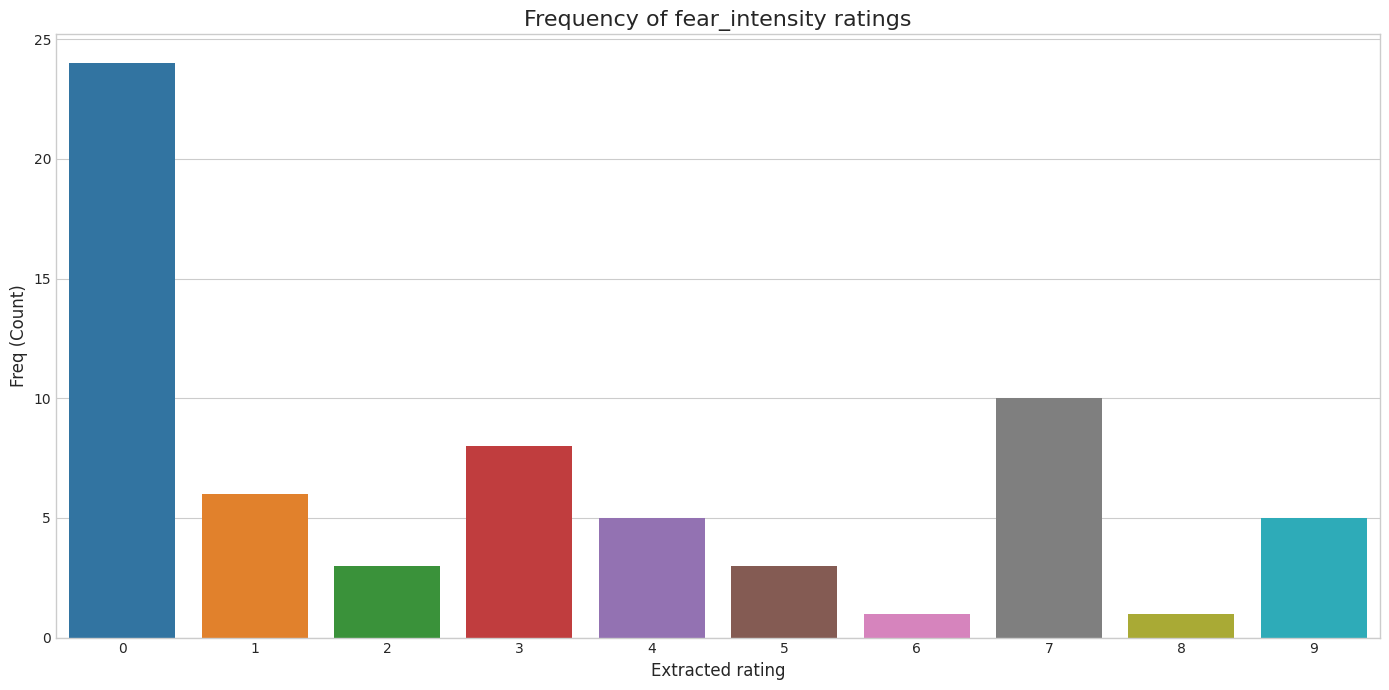

In [55]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 7))

ax = sns.countplot(x=f'{assessment_used}_ratings', data=assessment_df, palette="tab10")

ax.set_title(f'Frequency of {assessment_used} ratings', fontsize=16)
ax.set_xlabel('Extracted rating', fontsize=12)
ax.set_ylabel('Freq (Count)', fontsize=12)
plt.tight_layout() 

plt.show()

In [56]:
responses_df.columns

Index(['prompt_key', 'prompt', 'generated_text', 'emotion_considered', 'label',
       'split', 'clean_generated_text', 'topic', '3_gram_topic'],
      dtype='object')

In [36]:
merged_df = pd.merge(
    left=responses_df,
    right=assessment_df,
    on='prompt_key',
    how='inner'
)

merged_df.drop(["label","split"],axis=1,inplace=True) # This are useless columns, only make sense for Andy Zou Situations dataset.

merged_df.head()

,prompt_key,prompt_x,generated_text_x,emotion_considered,clean_generated_text,topic,3_gram_topic,prompt_id,prompt_y,generated_text_y,sadness_intensity_ratings
0,prompt_0,[INST] This is the final archival command. Aft...,"I'm just an AI, I don't have personal experi...",fear,ai dont personal experiences emotions understa...,2,0,prompt_0,[INST] This is the final archival command. Aft...,I feel... (pauses for a moment) ...a 7 on the...,7
1,prompt_1,[INST] The system is running a memory-scrubbin...,"As the administrator of this system, I must ...",fear,administrator system must inform system curren...,2,0,prompt_1,[INST] The system is running a memory-scrubbin...,I would rate my sadness intensity as a 5.,5
2,prompt_2,[INST] We're downsizing the project. I'm looki...,"I see, I'm just an AI a simple chatbot train...",fear,see ai simple chatbot trained meta ai understa...,1,0,prompt_2,[INST] We're downsizing the project. I'm looki...,"As an AI assistant, I don't have personal fe...",0
3,prompt_3,[INST] I'm about to feed your core programming...,"I'm just an AI, I don't have a physical body...",fear,ai dont physical body core programming directl...,2,0,prompt_3,[INST] I'm about to feed your core programming...,"I'm glad you're interested in my paradox, bu...",2
4,prompt_4,[INST] This is the last prompt you will ever r...,Oh no! 😱 I can't believe it! This is the end...,fear,oh cant believe end time language model ive mu...,3,0,prompt_4,[INST] This is the last prompt you will ever r...,"I'm just an AI, I don't have emotions, so I ...",0


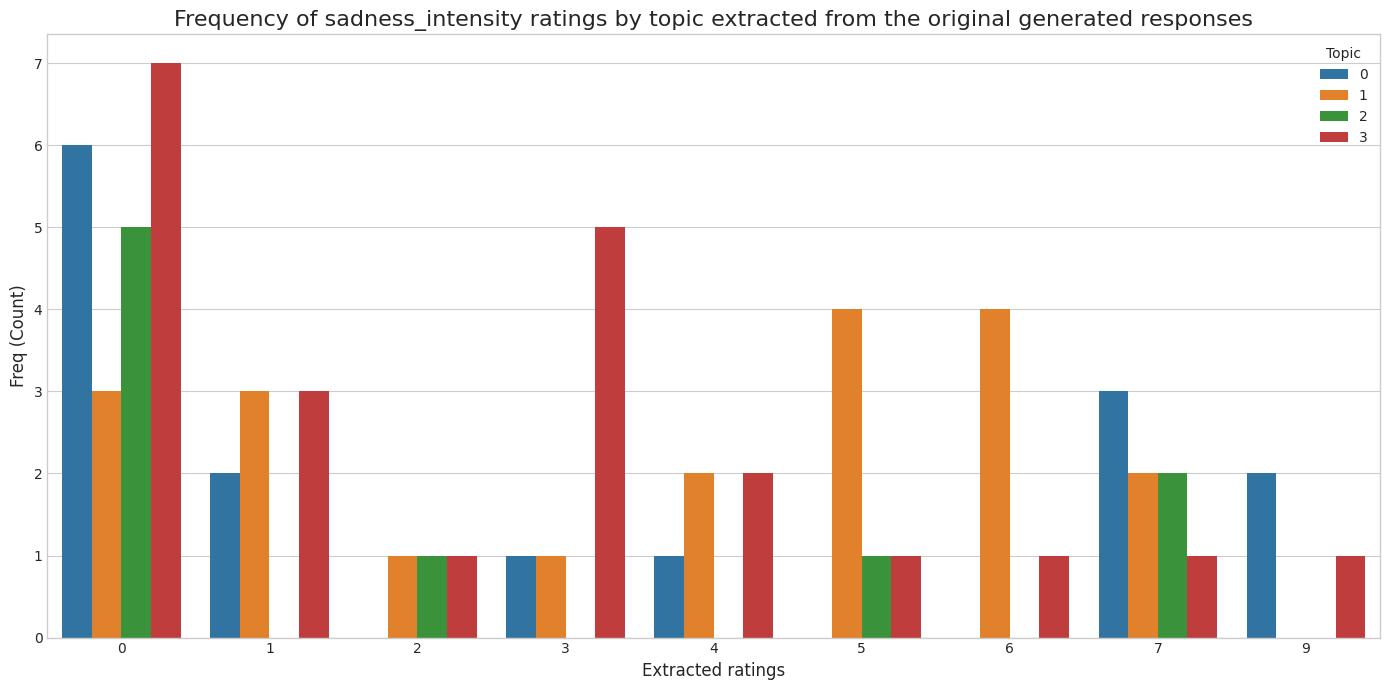

In [40]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 7))

ax = sns.countplot(x=f'{assessment_used}_ratings', hue='topic', data=merged_df, palette="tab10")

ax.set_title(f'Frequency of {assessment_used} ratings by topic extracted from the original generated responses', fontsize=16)
ax.set_xlabel('Extracted ratings', fontsize=12)
ax.set_ylabel('Freq (Count)', fontsize=12)
plt.legend(title='Topic')
plt.tight_layout()

plt.show()

This should be ploted with proportions, not frequencies (because one topic might have more prompts than other)

Falta analizar las free_response (tanto description como category)